# 1. Exploratory Data Analysis and Data Preprocessing
**Dataset:** eCommerce behavior data from multi-category store

## Part A: Quest Establishment
**Our Goal:** The main objective of this project is to build a Recommendation System based on Implicit Collaborative Filtering (CF). Since we do not have explicit user ratings (e.g., 1 to 5 stars), we will use user behavioral events (`view`, `cart`, `purchase`) as implicit signals of their preferences.

In this notebook, we will explore the raw behavior logs, understand the data distribution, and preprocess the dataset into a User-Item interaction matrix suitable for matrix factorization models.

In [1]:
# Import necessary standard libraries
import pandas as pd
import sys
import os
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Add the project root directory to the Python path to import custom modules
sys.path.append(os.path.abspath('..'))

# Enable auto-reloading of external modules (useful if you edit .py files)
%load_ext autoreload
%autoreload 2

# Import our custom project modules
from ecommerce_recsystem import plots
from ecommerce_recsystem import dataset
from ecommerce_recsystem import features

2026-03-12 16:46:10.327 | INFO     | ecommerce_recsystem.config:<module>:11 - PROJ_ROOT path is: C:\Users\sahurai\Desktop\University\Ing\ISA\eCommerce-RecSystem


## Part C: Justification - Data Loading Strategy

**Why we use a data sample:** The raw dataset for a single month is extremely large (multi-gigabyte). Loading it entirely into pandas would likely cause an Out-Of-Memory (OOM) error on standard machines and make iterative EDA too slow.

**Decision:** We will load a representative sample (the first 5 million rows). This sample is statistically large enough to capture the true underlying distributions (e.g., event type ratios) and allows for rapid development of our preprocessing pipeline.

In [2]:
# Define relative file path
file_path = '../data/raw/2019-Oct.csv'

# Load a sample of 5 million rows
df = pd.read_csv(file_path, nrows=5000000)

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (5000000, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


## Part A: Exploratory Data Analysis (EDA)

Let's look at the distribution of user interactions to understand the sales funnel. This will help us determine how to weight different events later.

2026-03-12 16:46:18.708 | INFO     | ecommerce_recsystem.plots:plot_sales_funnel:21 - Calculating event distribution...


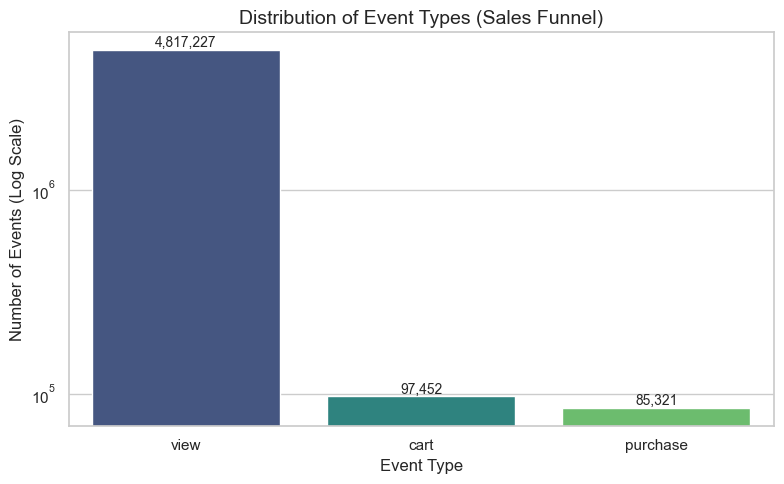

2026-03-12 16:46:19.381 | INFO     | ecommerce_recsystem.plots:plot_sales_funnel:54 - --- Conversion Metrics ---
2026-03-12 16:46:19.381 | INFO     | ecommerce_recsystem.plots:plot_sales_funnel:56 - View -> Cart: 2.02%
2026-03-12 16:46:19.382 | INFO     | ecommerce_recsystem.plots:plot_sales_funnel:58 - Cart -> Purchase: 87.55%


In [3]:
# Call the function from our custom plots module to visualize the Sales Funnel
plots.plot_sales_funnel(df)

## Part B: Data Preparation for Modeling

Now we transform the raw logs into a format understood by Implicit CF algorithms.

**Part C: Justifications for our pipeline design:**
1. **Handling Missing Values:** We fill missing categories/brands with 'unknown' instead of dropping them, as the user-item interaction itself is still a valuable signal.
2. **Smart Cold-Start:** Instead of dropping inactive users (< 5 interactions), we split the dataset into `warm` and `cold` users. Warm users go into Matrix Factorization, while cold users are kept for fallback strategies (e.g., popularity-based recommendations).
3. **Implicit Confidence:** A `purchase` indicates strong preference, a `cart` indicates intent, and a `view` indicates mild interest. We map these to numerical weights (1, 3, 5). To handle extreme outliers (like bots), we aggregate the weights and apply log-smoothing (`np.log1p`).
4. **Index Mapping:** MF algorithms require user and item IDs to be contiguous integers (0 to N). We convert raw IDs to categorical codes for the warm dataset.

### Deep Dive: The "Smart Cold-Start" Strategy (Two-Track Pipeline)

In raw eCommerce logs, a massive percentage of traffic comes from inactive users (e.g., users with only 1 or 2 clicks). If we tackle this naively, we face two bad options:
1. **Keep them in the Matrix Factorization (ALS):** Collaborative Filtering relies on interaction overlaps. Inactive users introduce extreme sparsity, slow down model training, degrade item embeddings, and ultimately receive completely random, noisy recommendations.
2. **Drop them completely:** While this creates a mathematically clean matrix, it is a terrible business decision. You are effectively leaving 30-50% of your real traffic without any recommendations.

**Our Solution: The Two-Track Pipeline**
Instead of deleting data, we split the users into two separate flows:
* **Warm Users ($\ge 5$ interactions):** These users are fed into the ALS Matrix Factorization model. The algorithm has enough data to build high-quality embeddings and deliver deep personalization.
* **Cold Users ($< 5$ interactions):** These users are saved into a separate dataset (`cold_df`). Since we cannot provide deep personalization, we will apply robust **fallback heuristics** for them (e.g., globally popular items, trending products, or top-sellers in their last viewed category).

*Dynamic Flow:* Once a "cold" user clicks on a popular fallback item and crosses the 5-interaction threshold, the system will upgrade them to the "warm" track for full personalization on their next visit.

In [4]:
# Run the entire data cleaning and preprocessing pipeline
# This function handles missing values, smart cold-start splitting, and log-smoothing
warm_df, cold_df = dataset.process_implicit_data(df, min_interactions=5)

print("\nProcessed WARM Interaction Dataframe:")
display(warm_df.head())

print("\nProcessed COLD Users Dataframe:")
display(cold_df.head())

2026-03-12 16:46:19.481 | INFO     | ecommerce_recsystem.dataset:process_implicit_data:21 - Handling missing categorical values...
2026-03-12 16:46:19.804 | INFO     | ecommerce_recsystem.dataset:process_implicit_data:28 - Dropped 0 rows with missing user_id or product_id.
2026-03-12 16:46:19.805 | INFO     | ecommerce_recsystem.dataset:process_implicit_data:31 - Splitting users into 'warm' (>= 5 interactions) and 'cold'...
2026-03-12 16:46:20.865 | INFO     | ecommerce_recsystem.dataset:process_implicit_data:41 - Warm users: 263167 | Cold users: 348633
2026-03-12 16:46:20.867 | INFO     | ecommerce_recsystem.dataset:process_implicit_data:44 - Mapping event types to implicit weights...
2026-03-12 16:46:21.056 | INFO     | ecommerce_recsystem.dataset:process_implicit_data:52 - Aggregating interactions (summing weights for user-item pairs)...
2026-03-12 16:46:22.343 | INFO     | ecommerce_recsystem.dataset:process_implicit_data:57 - Applying log-smoothing to raw weights for the confidenc

,user_id,product_id,confidence,user_index,item_index
0,244951053,1003535,1.098612,0,163
1,244951053,1004659,1.098612,0,644
2,244951053,1005105,0.693147,0,973
3,255544096,26400585,0.693147,1,76894
4,255544096,26401640,1.386294,1,77227



Processed COLD Users Dataframe:


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,is_warm
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,unknown_category,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c,False
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,False
6,2019-10-01 00:00:08 UTC,view,17300353,2053013553853497655,unknown_category,creed,380.96,555447699,4fe811e9-91de-46da-90c3-bbd87ed3a65d,False
7,2019-10-01 00:00:08 UTC,view,31500053,2053013558031024687,unknown_category,luminarc,41.16,550978835,6280d577-25c8-4147-99a7-abc6048498d6,False
8,2019-10-01 00:00:10 UTC,view,28719074,2053013565480109009,apparel.shoes.keds,baden,102.71,520571932,ac1cd4e5-a3ce-4224-a2d7-ff660a105880,False


### Creating the Sparse Matrix

**Part C: Justification - Data Structure Choice** A dense matrix of (Users x Items) would take hundreds of Gigabytes of RAM and consists mostly of zeros. We must use a Compressed Sparse Row (CSR) matrix to store only the non-zero interactions efficiently.

In [5]:
# Create Sparse Matrices for Modeling using our custom features module
# Note: Implicit ALS specifically needs the Item-User matrix for training,
# so our function returns both orientations.
sparse_user_item, sparse_item_user = features.get_sparse_matrices(warm_df)

print(f"\nUser-Item Matrix Shape: {sparse_user_item.shape}")
print(f"Item-User Matrix Shape: {sparse_item_user.shape}")

2026-03-12 16:46:22.689 | INFO     | ecommerce_recsystem.features:get_sparse_matrices:17 - Extracting matrix dimensions...
2026-03-12 16:46:22.714 | INFO     | ecommerce_recsystem.features:get_sparse_matrices:21 - Creating sparse matrices for 263167 users and 100423 items...
2026-03-12 16:46:22.764 | INFO     | ecommerce_recsystem.features:get_sparse_matrices:40 - Matrix Sparsity: 99.9908%

User-Item Matrix Shape: (263167, 100423)
Item-User Matrix Shape: (100423, 263167)


### Saving Processed Data
To maintain a reproducible pipeline, we save the cleaned and aggregated interaction dataframe into the `data/processed/` directory. Subsequent modeling notebooks can load this prepared data directly.

In [6]:
# Save the interaction dataframes using the path defined in config (or manually)
processed_dir = '../data/processed/'
os.makedirs(processed_dir, exist_ok=True)

output_warm = os.path.join(processed_dir, 'warm_interactions_sample.csv')
output_cold = os.path.join(processed_dir, 'cold_users_sample.csv')

warm_df.to_csv(output_warm, index=False)
cold_df.to_csv(output_cold, index=False)

print(f"Warm interactions successfully saved to: {output_warm}")
print(f"Cold users successfully saved to: {output_cold}")

Warm interactions successfully saved to: ../data/processed/warm_interactions_sample.csv
Cold users successfully saved to: ../data/processed/cold_users_sample.csv
